# Optimización de costo de operación de Microrred con Generadores Diesel
**MILP, UC, scheduling**  

V1: Adaptado a PYOMO desde la implementación original en [https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html](https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html) y en el Ejemplo 12.15 del libro [Model Building in Mathematical Programming](https://share.google/ovWcmGq54LiyOcWm8) de H. Paul Williams (5ª edición, págs. 270-271 y 325-326).

Formulación MILP con:
- Satisfacción exacta de la demanda por período
- Restricción de reserva operativa (15% sobre la demanda)
- Costos fijos por generador activo, costos marginales y costos de arranque
- Objetivo: minimizar costo total de operación

V2: El problema de Williams de despacho nacional (≈ 45 GW) redimensionado a escala de microrred (≈ 2.1 MW pico). Se reeplazaron los generadores térmicos por generadores diesel.

## Problema: Gestión Energética de Microrred con generación diesel

Una flota de 27 grupos generadores diesel está disponible para satisfacer la demanda eléctrica de una microrred aislada a lo largo de un día:

| Periodo | Horario       | Demanda (kW) |
| :------ | :------------ | :----------- |
| 1       | 00:00 a 5:59  | 790          |
| 2       | 6:00 a 8:59   | 1575         |
| 3       | 9:00 a 14:59  | 1312         |
| 4       | 15:00 a 17:59 | 2100         |
| 5       | 18:00 a 23:59 | 1417         |

Hay tres tipos de generadores diesel disponibles, 12 pequeños (40 KW), 10 medianos (100 KW) y 5 grandes (250 KW). Cada generador opera entre un nivel mínimo (50% de capacidad nominal) y un nivel máximo. Existen costos de O&M (operación y mantenimiento) fijos, costos de combustible (modelados con curva cuadrática linealizada), costos de arranque y de apagado. Adicionalmente, cada unidad debe permanecer encendida/apagada un tiempo mínimo tras cada transición de estado.

La capacidad total instalada es 2.730 kW (12×40 + 10×100 + 5×250). Considerando la reserva del 15%, la demanda máxima factible es ≈ 2.374 kW, por lo que el pico de 2.100 kW tiene margen de seguridad. La tabla completa se muestra en la sección **Carga de Datos**

In [75]:
import pyomo.environ as pe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

## Carga de Datos

In [76]:
generator_data = pd.read_csv(
    "data/generators_diesel_v2.csv",
    index_col="generator_class",
)
generator_data

,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,state0
generator_class,,,,,,,,,
diesel_small,12,20.0,40.0,2.5,5.0,2.5,1,1,12
diesel_med,10,50.0,100.0,5.8,12.0,6.0,1,1,7
diesel_large,5,125.0,250.0,14.5,25.0,12.5,1,1,5


In [77]:
time_period_data = pd.read_csv(
    "data/time_periods_v2.csv",
    parse_dates=["time_period"],
    index_col="time_period",
)
time_period_data

,expected_demand,minimum_active_capacity
time_period,,
2024-01-01 00:00:00,790,908.50
2024-01-01 06:00:00,1575,1811.25
2024-01-01 09:00:00,1312,1508.80
2024-01-01 15:00:00,2100,2415.00
2024-01-01 18:00:00,1417,1629.55


## Conjuntos

In [78]:
GENERATORS   = list(generator_data.index)        # ['diesel_small', 'diesel_med', 'diesel_large']
TIME_PERIODS = list(time_period_data.index)       # lista de timestamps (5 períodos)
T            = list(range(len(TIME_PERIODS)))     # índices enteros 0..4 para Pyomo

print(f"Clases de generadores : {GENERATORS}")
print(f"Número de períodos    : {len(T)}")

Clases de generadores : ['diesel_small', 'diesel_med', 'diesel_large']
Número de períodos    : 5


## Parámetros

Los parámetros del modelo se construyen como diccionarios Python a partir de los DataFrames cargados.

- $n_g$: unidades disponibles de la clase $g$
- $P^{\min}_g$, $P^{\max}_g$: límites de producción por unidad [kW]
- $c_g$: costo fijo de O&M por hora por unidad activa [$/h]
- $s^u_g$: costo de arranque [$]
- $s^d_g$: costo de apagado [$]
- $\tau^{\mathrm{up}}_g$, $\tau^{\mathrm{dn}}_g$: tiempos mínimos de encendido/apagado [períodos]
- $a^0_g$: estado inicial (unidades activas antes del primer período)
- $D_t$: demanda esperada en el período $t$ [kW]
- $\bar{D}_t$: capacidad activa mínima requerida en el período $t$ [kW]
- $S_j^g$, $s_j^g$: pendiente e intercepto del segmento $j$ de la curva de combustible de la clase $g$

In [79]:
# ── Parámetros por clase de generador ───────────────────────────────────────
num_available = generator_data['num_available'].to_dict()
min_output    = generator_data['min_output'].to_dict()
max_output    = generator_data['max_output'].to_dict()
cost_per_hour = generator_data['cost_per_hour'].to_dict()
startup_cost  = generator_data['startup_cost'].to_dict()
shutdown_cost = generator_data['shutdown_cost'].to_dict()
min_up_time   = generator_data['min_up_time'].to_dict()
min_down_time = generator_data['min_down_time'].to_dict()
state0        = generator_data['state0'].to_dict()

# ── Parámetros por período (indexados por entero) ────────────────────────────
expected_demand         = {i: time_period_data['expected_demand'].iloc[i]         for i in T}
minimum_active_capacity = {i: time_period_data['minimum_active_capacity'].iloc[i] for i in T}

## Linealización de la Curva de Costo de Combustible
### Enfoque Parisio (2014)

Dado que los MILP son computacionalmente más eficientes que los MIQP, la función de costo de combustible de un generador diesel:

$$f(P) = a P^2 + b P \quad [\text{\$/h}]$$

se aproxima por el máximo de funciones afines sin introducir variables binarias adicionales:

$$f(P) \approx \sigma = \max_{j=1,\dots,n}\{S_j P + s_j\}$$

donde los coeficientes de cada segmento $j$ se obtienen evaluando la tangente de $f$ en el punto de soporte $P_j$:

$$S_j = f'(P_j) = 2aP_j + b \qquad s_j = f(P_j) - S_j P_j = -aP_j^2$$

Extensión a clases de generadores (formulación agregada): si hay $n_{g,t}$ unidades activas de la clase $g$ produciendo $P^{\mathrm{D}}_{g,t}$ kW en total, el costo de combustible agregado es:

$$n_{g,t} \cdot f\!\left(\frac{P^{\mathrm{D}}_{g,t}}{n_{g,t}}\right) = a\frac{{P^{\mathrm{D}}_{g,t}}^2}{n_{g,t}} + b\, P^{\mathrm{D}}_{g,t}$$

Con la aproximación lineal tangente en cada punto de soporte, esto se convierte en el conjunto de restricciones lineales:

$$\sigma_{g,t} \geq S_j^{g} \cdot P^{\mathrm{D}}_{g,t} + s_j^{g} \cdot n_{g,t} \qquad \forall j = 1, \dots, n_{\mathrm{seg}}$$

Esta formulación es lineal porque $S_j^{g}$ y $s_j^{g}$ son constantes, $P^{\mathrm{D}}_{g,t}$ es continua y $n_{g,t}$ es entera.

Se definen los coeficientes cuadráticos de la función de costo de combustible por unidad:

$$f_g(P) = a_g P^2 + b_g P \quad [\text{\$/h}]$$

y se calculan los segmentos lineales evaluando las tangentes en $n_{\mathrm{seg}} = 3$ puntos de soporte equidistantes entre $P^{\min}_g$ y $P^{\max}_g$.

Los coeficientes (Tabla 2.1 de Nemati) $a$ en $ml/kW^{2}h$ y $b$ en $l/kWh$ se multiplicaron por un precio de combustible estimado de $1.2 $/l$.


In [80]:
# ── Coeficientes de la curva cuadrática de combustible por clase ─────────────
# f(P) = a·P² + b·P  [$/h],  P en kW
# Los valores de 'a' capturan la no linealidad del consumo específico de combustible.
# Los valores de 'b' son consistentes con el costo marginal a carga media.
quad_params = {
    'diesel_small': {'a': 0.003,   'b': 0.18},   # $/(kW²·h), $/(kW·h)
    'diesel_med':   {'a': 0.0012,  'b': 0.20},
    'diesel_large': {'a': 0.0004,  'b': 0.22},
}

N_SEG = 3   # número de puntos de soporte para la linealización

# ── Cálculo de segmentos lineales ─────────────────────────────────────────────
# En cada punto P_j:
#   S_j = f'(P_j) = 2·a·P_j + b      (pendiente)
#   s_j = f(P_j) - S_j·P_j = -a·P_j² (intercepto por unidad)
lin_segments = {}   # {g: {'slopes': [...], 'intercepts': [...]}}

for g in GENERATORS:
    a  = quad_params[g]['a']
    b  = quad_params[g]['b']
    p_min = min_output[g]
    p_max = max_output[g]
    
    support_points = np.linspace(p_min, p_max, N_SEG)
    slopes     = [2 * a * pj + b for pj in support_points]
    intercepts = [-a * pj**2      for pj in support_points]
    lin_segments[g] = {'slopes': slopes, 'intercepts': intercepts, 'support': support_points}

SEGMENTS = list(range(N_SEG))   # índices de segmento: 0, 1, 2

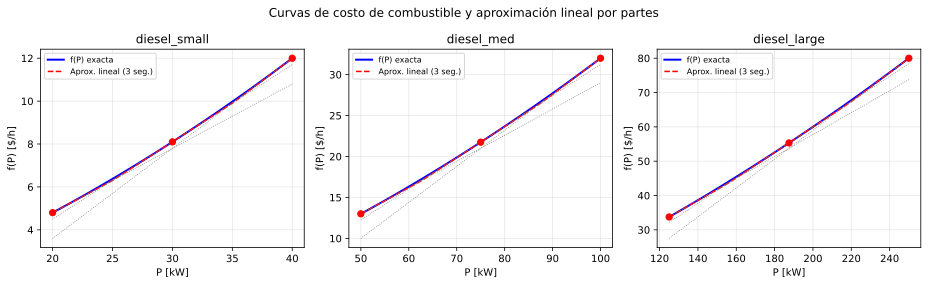

In [81]:
# ── Visualización de las curvas y su aproximación ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Curvas de costo de combustible y aproximación lineal por partes", fontsize=12)

for ax, g in zip(axes, GENERATORS):
    a = quad_params[g]['a']
    b = quad_params[g]['b']
    p_min, p_max = min_output[g], max_output[g]
    
    P = np.linspace(p_min, p_max, 200)
    f_exact = a * P**2 + b * P
    
    # Aproximación por máximo de rectas
    segs = lin_segments[g]
    f_approx = np.max(
        np.array([segs['slopes'][j] * P + segs['intercepts'][j] for j in SEGMENTS]), axis=0
    )
    
    ax.plot(P, f_exact,  'b-',  lw=2,   label='f(P) exacta')
    ax.plot(P, f_approx, 'r--', lw=1.5, label='Aprox. lineal (3 seg.)')
    for j in SEGMENTS:
        Sj = segs['slopes'][j]; sj = segs['intercepts'][j]
        ax.plot(P, Sj * P + sj, 'gray', lw=0.8, ls=':')
    ax.scatter(segs['support'], [a*pj**2 + b*pj for pj in segs['support']],
               color='red', zorder=5, s=40)
    ax.set_xlabel("P [kW]"); ax.set_ylabel("f(P) [$/h]")
    ax.set_title(g); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
# ── Tabla resumen de segmentos ────────────────────────────────────────────────
print("\nSegmentos lineales de la curva de combustible:")
print(f"{'Clase':<14} {'Seg':>4} {'P_soporte (kW)':>16} {'Pendiente S_j':>15} {'Intercepto s_j':>16}")
print("-" * 68)
for g in GENERATORS:
    segs = lin_segments[g]
    for j in SEGMENTS:
        print(f"{g:<14} {j:>4} {segs['support'][j]:>16.1f} {segs['slopes'][j]:>15.5f} {segs['intercepts'][j]:>16.4f}")
    print()


Segmentos lineales de la curva de combustible:
Clase           Seg   P_soporte (kW)   Pendiente S_j   Intercepto s_j
--------------------------------------------------------------------
diesel_small      0             20.0         0.30000          -1.2000
diesel_small      1             30.0         0.36000          -2.7000
diesel_small      2             40.0         0.42000          -4.8000

diesel_med        0             50.0         0.32000          -3.0000
diesel_med        1             75.0         0.38000          -6.7500
diesel_med        2            100.0         0.44000         -12.0000

diesel_large      0            125.0         0.32000          -6.2500
diesel_large      1            187.5         0.37000         -14.0625
diesel_large      2            250.0         0.42000         -25.0000



## Construcción del Modelo Pyomo

In [83]:
model = pe.ConcreteModel(name="UC_Microgrid_Diesel")

## Conjuntos del Modelo

In [84]:
model.G = pe.Set(initialize=GENERATORS, doc="Clases de generadores diesel")
model.T = pe.Set(initialize=T, ordered=True, doc="Períodos de tiempo (índices enteros)")
model.J = pe.Set(initialize=SEGMENTS, doc="Segmentos de linealización de costo combustible")

## Parámetros del Modelo

In [85]:
model.num_available           = pe.Param(model.G, initialize=num_available,           doc="Unidades disponibles")
model.min_output              = pe.Param(model.G, initialize=min_output,              doc="Producción mínima [kW]")
model.max_output              = pe.Param(model.G, initialize=max_output,              doc="Producción máxima [kW]")
model.cost_per_hour           = pe.Param(model.G, initialize=cost_per_hour,           doc="Costo fijo O&M [$/h]")
model.startup_cost            = pe.Param(model.G, initialize=startup_cost,            doc="Costo de arranque [$]")
model.shutdown_cost           = pe.Param(model.G, initialize=shutdown_cost,           doc="Costo de apagado [$]")
model.min_up_time             = pe.Param(model.G, initialize=min_up_time,             doc="Tiempo mínimo encendido [períodos]")
model.min_down_time           = pe.Param(model.G, initialize=min_down_time,           doc="Tiempo mínimo apagado [períodos]")
model.state0                  = pe.Param(model.G, initialize=state0,                  doc="Estado inicial")
model.expected_demand         = pe.Param(model.T, initialize=expected_demand,         doc="Demanda esperada [kW]")
model.minimum_active_capacity = pe.Param(model.T, initialize=minimum_active_capacity, doc="Capacidad activa mínima [kW]")

# ── Parámetros de linealización (indexados por clase × segmento) ─────────────
slope_data     = {(g, j): lin_segments[g]['slopes'][j]     for g in GENERATORS for j in SEGMENTS}
intercept_data = {(g, j): lin_segments[g]['intercepts'][j] for g in GENERATORS for j in SEGMENTS}

model.lin_slope     = pe.Param(model.G, model.J, initialize=slope_data,     doc="Pendiente S_j del segmento j de la clase g")
model.lin_intercept = pe.Param(model.G, model.J, initialize=intercept_data, doc="Intercepto s_j del segmento j de la clase g")

## Variables de Decisión

### Variables Continuas

| Variable | Índices | Dominio | Unidad | Descripción |
| :--- | :---: | :---: | :---: | :--- |
| $P^{\mathrm{D}}_{g,t}$ (`output`) | $g \in G,\; t \in T$ | $\mathbb{R}_{\geq 0}$ | kW | Producción total de la clase $g$ en el período $t$ |
| $\sigma_{g,t}$ (`sigma`) | $g \in G,\; t \in T$ | $\mathbb{R}_{\geq 0}$ | $/h | Costo de combustible total de la clase $g$ en $t$ (variable auxiliar de linealización) |

### Variables Enteras

| Variable | Índices | Dominio | Unidad | Descripción |
| :--- | :---: | :---: | :---: | :--- |
| $n_{g,t}$ (`num_active`) | $g \in G,\; t \in T$ | $\{0, 1, \ldots, n_g\}$ | unidades | Número de generadores de la clase $g$ activos en el período $t$ |
| $u_{g,t}$ (`num_startup`) | $g \in G,\; t \in T$ | $\mathbb{Z}_{\geq 0}$ | unidades | Número de generadores de la clase $g$ que **arrancan** en el período $t$ |
| $v_{g,t}$ (`num_shutdown`) | $g \in G,\; t \in T$ | $\mathbb{Z}_{\geq 0}$ | unidades | Número de generadores de la clase $g$ que **se apagan** en el período $t$ |

### Relación entre Variables de Transición de Estado

Las variables enteras satisfacen la identidad de balance:

$$n_{g,t} - n_{g,t-1} = u_{g,t} - v_{g,t} \qquad \forall g,\; t > t_0$$

que se implementa mediante las cotas inferiores separadas para arranques y apagados.

### Dimensiones del Modelo

| Tipo | Cantidad |
| :--- | :---: |
| Clases de generadores ($\|G\|$) | 3 |
| Períodos de tiempo ($\|T\|$) | 5 |
| Segmentos de linealización ($\|J\|$) | 3 |
| Variables continuas (`output` + `sigma`) | $2 \times \|G\| \times \|T\|$ = **30** |
| Variables enteras (`num_active` + `num_startup` + `num_shutdown`) | $3 \times \|G\| \times \|T\|$ = **45** |
| **Total variables** | **75** |

In [86]:
# ── Variable continua: producción total de la clase g en el período t [kW] ──
model.output = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeReals,
    doc="Producción total [kW]"
)

# ── Variable continua: costo de combustible total clase g en período t [$/h] ─
# Variable auxiliar de linealización Parisio: sigma_{g,t} = max_j { S_j·x + s_j·n }
model.sigma = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeReals,
    doc="Costo total de combustible [$/h] — variable de linealización Parisio"
)

# ── Variable entera: generadores activos (cota superior = num_available[g]) ──
def num_active_bounds(m, g, t):
    return (0, m.num_available[g])

model.num_active = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeIntegers,
    bounds=num_active_bounds,
    doc="Número de generadores activos"
)

# ── Variable entera: generadores que arrancan en el período t ─────────────────
model.num_startup = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeIntegers,
    doc="Número de arranques por período"
)

# ── Variable entera: generadores que se apagan en el período t ───────────────
model.num_shutdown = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeIntegers,
    doc="Número de apagados por período"
)

## Restricciones

### 1. Satisfacción de la Demanda

La producción total de todos los generadores en cada período debe igualar la demanda prevista:

$$\sum_{g \in G} P^{\mathrm{D}}_{g,t} = D_t \qquad \forall t \in T$$

In [87]:
def demand_rule(m, t):
    return sum(m.output[g, t] for g in m.G) == m.expected_demand[t]

model.demand_constraint = pe.Constraint(
    model.T, rule=demand_rule,
    doc="Producción total = demanda esperada"
)

### 2. Restricción de Reserva Operativa

Los generadores activos deben tener capacidad suficiente para cubrir un 15% adicional de demanda ajustando la producción de las unidades ya encendidas:

$$\sum_{g \in G} P^{\max}_g \cdot n_{g,t} \geq \bar{D}_t \qquad \forall t \in T$$

In [88]:
def reserve_rule(m, t):
    return sum(m.max_output[g] * m.num_active[g, t] for g in m.G) >= m.minimum_active_capacity[t]

model.reserve_constraint = pe.Constraint(
    model.T, rule=reserve_rule,
    doc="Capacidad activa máxima >= capacidad mínima requerida"
)

### 3. Límites de Producción por Unidad Activa

Cada generador activo opera entre su mínimo técnico y su máximo técnico:

$$P^{\min}_g \cdot n_{g,t} \leq P^{\mathrm{D}}_{g,t} \leq P^{\max}_g \cdot n_{g,t} \qquad \forall g \in G, t \in T$$

In [89]:
def output_lower_rule(m, g, t):
    return m.output[g, t] >= m.min_output[g] * m.num_active[g, t]

model.output_lower = pe.Constraint(
    model.G, model.T, rule=output_lower_rule,
    doc="Producción >= mínimo × generadores activos"
)

def output_upper_rule(m, g, t):
    return m.output[g, t] <= m.max_output[g] * m.num_active[g, t]

model.output_upper = pe.Constraint(
    model.G, model.T, rule=output_upper_rule,
    doc="Producción <= máximo × generadores activos"
)

### 4. Balance de Estado: Arranques

La variable $u_{g,t}$ captura el incremento neto de unidades activas entre períodos.

**Períodos $t > t_0$:**
$$u_{g,t} \geq n_{g,t} - n_{g,t-1} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Primer período $t_0$:**
$$u_{g,t_0} \geq n_{g,t_0} - a^0_g \qquad \forall g \in G$$

In [90]:
def startup_rule(m, g, t):
    if t == m.T.first():
        return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    return m.num_startup[g, t] >= m.num_active[g, t] - m.num_active[g, t_prev]

model.startup_constraint = pe.Constraint(
    model.G, model.T, rule=startup_rule,
    doc="Arranques en t >= incremento de activos respecto a t-1"
)

def initial_startup_rule(m, g):
    t0 = m.T.first()
    return m.num_startup[g, t0] >= m.num_active[g, t0] - m.state0[g]

model.initial_startup = pe.Constraint(
    model.G, rule=initial_startup_rule,
    doc="Arranques en t₀ >= activos en t₀ − estado inicial"
)

### 5. Balance de Estado: Apagados

Simétricamente, $v_{g,t}$ captura el decremento neto de unidades activas.

**Períodos $t > t_0$:**
$$v_{g,t} \geq n_{g,t-1} - n_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Primer período $t_0$:**
$$v_{g,t_0} \geq a^0_g - n_{g,t_0} \qquad \forall g \in G$$

In [91]:
def shutdown_rule(m, g, t):
    if t == m.T.first():
        return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    return m.num_shutdown[g, t] >= m.num_active[g, t_prev] - m.num_active[g, t]

model.shutdown_constraint = pe.Constraint(
    model.G, model.T, rule=shutdown_rule,
    doc="Apagados en t >= decremento de activos respecto a t-1"
)

def initial_shutdown_rule(m, g):
    t0 = m.T.first()
    return m.num_shutdown[g, t0] >= m.state0[g] - m.num_active[g, t0]

model.initial_shutdown = pe.Constraint(
    model.G, rule=initial_shutdown_rule,
    doc="Apagados en t₀ >= estado inicial − activos en t₀"
)

### 6. Tiempo Mínimo de Encendido (Min Up-Time)

Si la clase $g$ arranca $u_{g,k}$ unidades en el período $k$, todas deben permanecer encendidas durante al menos $\tau^{\mathrm{up}}_g$ períodos consecutivos:

$$\sum_{k=t-\tau^{\mathrm{up}}_g+1}^{t} u_{g,k} \leq n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{up}}_g$$

Esto garantiza que las unidades arrancadas en el horizonte $[t-\tau^{\mathrm{up}}+1,\, t]$ estén activas en $t$.

In [92]:
def min_up_time_rule(m, g, t):
    mut = int(pe.value(m.min_up_time[g]))
    if mut <= 1:
        return pe.Constraint.Skip   # trivialmente satisfecho con las restricciones de arranque
    t_list = list(m.T)
    if t < mut - 1:
        return pe.Constraint.Skip
    # Suma de arranques en la ventana [t-mut+1 .. t]
    window = [t_list[k] for k in range(t - mut + 1, t + 1) if k >= 0]
    return sum(m.num_startup[g, tau] for tau in window) <= m.num_active[g, t_list[t]]

model.min_up_time_constraint = pe.Constraint(
    model.G, model.T, rule=min_up_time_rule,
    doc="Tiempo mínimo de encendido: unidades arrancadas deben permanecer activas MUT períodos"
)

### 7. Tiempo Mínimo de Apagado (Min Down-Time)

Simétricamente, las unidades apagadas en el período $k$ deben permanecer apagadas durante al menos $\tau^{\mathrm{dn}}_g$ períodos:

$$\sum_{k=t-\tau^{\mathrm{dn}}_g+1}^{t} v_{g,k} \leq n_g - n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{dn}}_g$$

In [93]:
def min_down_time_rule(m, g, t):
    mdt = int(pe.value(m.min_down_time[g]))
    if mdt <= 1:
        return pe.Constraint.Skip
    t_list = list(m.T)
    if t < mdt - 1:
        return pe.Constraint.Skip
    window = [t_list[k] for k in range(t - mdt + 1, t + 1) if k >= 0]
    return sum(m.num_shutdown[g, tau] for tau in window) <= m.num_available[g] - m.num_active[g, t_list[t]]

model.min_down_time_constraint = pe.Constraint(
    model.G, model.T, rule=min_down_time_rule,
    doc="Tiempo mínimo de apagado: unidades cerradas deben permanecer inactivas MDT períodos"
)

### 8. Linealización de la Curva de Combustible (Enfoque Parisio)

Para cada segmento $j$ de la aproximación lineal, se impone que $\sigma_{g,t}$ sea mayor o igual al costo de combustible calculado con la recta tangente en el punto de soporte $j$:

$$\sigma_{g,t} \geq S_j^g \cdot P^{\mathrm{D}}_{g,t} + s_j^g \cdot n_{g,t} \qquad \forall g \in G,\; t \in T,\; j \in J$$

Como $\sigma_{g,t}$ aparece con signo positivo en el objetivo (minimización), el solver lo fijará en el máximo de las rectas tangentes, reproduciendo la envolvente convexa de la curva cuadrática.

In [94]:
def fuel_cost_linearization_rule(m, g, t, j):
    return m.sigma[g, t] >= m.lin_slope[g, j] * m.output[g, t] + m.lin_intercept[g, j] * m.num_active[g, t]

model.fuel_cost_linearization = pe.Constraint(
    model.G, model.T, model.J, rule=fuel_cost_linearization_rule,
    doc="Linealización Parisio: sigma >= S_j·x + s_j·n para cada segmento j"
)

## Función Objetivo

Se minimiza el costo total de operación, compuesto por cuatro términos:

$$\min \sum_{g \in G} \sum_{t \in T} \left[
  \underbrace{c_g \cdot n_{g,t}}_{\text{O\&M fijo}}
  + \underbrace{\sigma_{g,t}}_{\text{combustible (Parisio)}}
  + \underbrace{s^u_g \cdot u_{g,t}}_{\text{arranque}}
  + \underbrace{s^d_g \cdot v_{g,t}}_{\text{apagado}}
\right]$$

La variable $\sigma_{g,t}$ reemplaza el término lineal de costo marginal de la formulación original, capturando la curvatura del consumo específico de combustible diesel.

In [95]:
def obj_rule(m):
    return sum(
        # Costo fijo de O&M por generadores activos
        m.cost_per_hour[g]  * m.num_active[g, t]
        # Costo de combustible (aproximación lineal Parisio)
        + m.sigma[g, t]
        # Costo de arranque
        + m.startup_cost[g]  * m.num_startup[g, t]
        # Costo de apagado
        + m.shutdown_cost[g] * m.num_shutdown[g, t]
        for g in m.G
        for t in m.T
    )

model.obj = pe.Objective(rule=obj_rule, sense=pe.minimize,
                          doc="Minimizar costo total de operación")

In [96]:
nG, nT, nJ = len(GENERATORS), len(T), N_SEG

print("=" * 60)
print("  RESUMEN DEL MODELO UC — MICRORRED DIESEL")
print("=" * 60)

print("\n── Conjuntos ────────────────────────────────────────")
print(f"  |G| Clases de generadores          : {nG}")
print(f"  |T| Períodos de tiempo             : {nT}")
print(f"  |J| Segmentos de linealización     : {nJ}")

print("\n── Variables continuas ──────────────────────────────")
print(f"  output  (x_{{g,t}})                  : {nG*nT:>4}  [kW]")
print(f"  sigma   (σ_{{g,t}})                  : {nG*nT:>4}  [$/h]")
print(f"  Subtotal continuas                 : {2*nG*nT:>4}")

print("\n── Variables enteras ────────────────────────────────")
print(f"  num_active   (n_{{g,t}})  ∈ [0, n_g] : {nG*nT:>4}  [unidades]")
print(f"  num_startup  (u_{{g,t}})  ≥ 0        : {nG*nT:>4}  [unidades]")
print(f"  num_shutdown (v_{{g,t}})  ≥ 0        : {nG*nT:>4}  [unidades]")
print(f"  Subtotal enteras                   : {3*nG*nT:>4}")

print(f"\n  TOTAL VARIABLES                    : {5*nG*nT:>4}")

print("\n── Restricciones ────────────────────────────────────")
print(f"  Demanda                            : {nT:>4}")
print(f"  Reserva operativa                  : {nT:>4}")
print(f"  Límites producción (inf + sup)     : {2*nG*nT:>4}")
print(f"  Arranque (t>t0 + inicial)          : {nG*(nT-1)+nG:>4}")
print(f"  Apagado  (t>t0 + inicial)          : {nG*(nT-1)+nG:>4}")
print(f"  Min up time                        : {nG*nT:>4}  (activas si MUT>1)")
print(f"  Min down time                      : {nG*nT:>4}  (activas si MDT>1)")
print(f"  Linealización combustible (|G||T||J|): {nG*nT*nJ:>4}")
print("=" * 60)

  RESUMEN DEL MODELO UC — MICRORRED DIESEL

── Conjuntos ────────────────────────────────────────
  |G| Clases de generadores          : 3
  |T| Períodos de tiempo             : 5
  |J| Segmentos de linealización     : 3

── Variables continuas ──────────────────────────────
  output  (x_{g,t})                  :   15  [kW]
  sigma   (σ_{g,t})                  :   15  [$/h]
  Subtotal continuas                 :   30

── Variables enteras ────────────────────────────────
  num_active   (n_{g,t})  ∈ [0, n_g] :   15  [unidades]
  num_startup  (u_{g,t})  ≥ 0        :   15  [unidades]
  num_shutdown (v_{g,t})  ≥ 0        :   15  [unidades]
  Subtotal enteras                   :   45

  TOTAL VARIABLES                    :   75

── Restricciones ────────────────────────────────────
  Demanda                            :    5
  Reserva operativa                  :    5
  Límites producción (inf + sup)     :   30
  Arranque (t>t0 + inicial)          :   15
  Apagado  (t>t0 + inicial)         

## Resolución del Modelo

Configuración del solver MILP. Ver [parámetros de GUROBI](https://docs.gurobi.com/projects/optimizer/en/current/concepts/parameters.html).

In [97]:
solver = pe.SolverFactory('gurobi_direct')
solver.options['MIPGap']    = 0      # 0% gap → óptimo garantizado
solver.options['MIPFocus']  = 1      # priorizar encontrar soluciones factibles
solver.options['OutputFlag']= 1      # mostrar log de Gurobi

t0 = time.time()
results = solver.solve(model, tee=True)
cpu_time = time.time() - t0

print(f"\nTiempo de CPU: {cpu_time:.2f} s")

Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0
Set parameter MIPFocus to value 1
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7430U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
MIPGap  0
MIPFocus  1

Academic license 2723234 - for non-commercial use only - registered to nz___@frsf.utn.edu.ar
Optimize a model with 115 rows, 75 columns and 309 nonzeros (Min)
Model fingerprint: 0xfcaa57c9
Model has 60 linear objective coefficients
Variable types: 30 continuous, 45 integer (0 binary)
Coefficient statistics:
  Matrix range     [3e-01, 3e+02]
  Objective range  [1e+00, 3e+01]
  Bounds range     [5e+00, 1e+01]
  RHS range        [5e+00, 2e+03]
Found heuristic solution: objective 3199.5250000
Presolve removed 4 rows and 4 columns
Presolve time: 0.00s


Presolved: 111 rows, 71 columns, 301 nonzeros
Variable types: 30 continuous, 41 integer (2 binary)

Root relaxation: objective 2.773387e+03, 92 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 2773.38720    0    5 3199.52500 2773.38720  13.3%     -    0s
H    0     0                    2832.3995000 2773.38720  2.08%     -    0s
H    0     0                    2821.8995000 2773.38720  1.72%     -    0s
H    0     0                    2781.3100000 2773.38720  0.28%     -    0s
H    0     0                    2779.5320000 2773.38720  0.22%     -    0s
H    0     0                    2776.9100000 2773.38720  0.13%     -    0s

Cutting planes:
  Gomory: 1

Explored 1 nodes (92 simplex iterations) in 0.04 seconds (0.00 work units)
Thread count was 12 (of 12 available processors)

Solution count 5: 2776.91 2781.31 2821.9 ... 3199.52

Op

## Verificación de la Solución

In [98]:
tc = results.solver.termination_condition

if tc == pe.TerminationCondition.optimal:
    print("Solución ÓPTIMA encontrada")
elif tc == pe.TerminationCondition.feasible:
    print("Solución FACTIBLE encontrada (límite de tiempo alcanzado)")
elif tc == pe.TerminationCondition.infeasible:
    print("Problema INFACTIBLE")
else:
    print(f"Estado del solver: {tc}")

costo_total = pe.value(model.obj)
print(f"\nCosto total óptimo : ${costo_total:,.2f}")
print(f"Tiempo de CPU      : {cpu_time:.2f} s")

Solución ÓPTIMA encontrada

Costo total óptimo : $2,776.91
Tiempo de CPU      : 0.10 s


## Extracción de Resultados

In [99]:
# ── Descomposición de costos por generador y período ─────────────────────────
rows = []
for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g, i])))
        ns  = int(round(pe.value(model.num_startup[g, i])))
        nd  = int(round(pe.value(model.num_shutdown[g, i])))
        out = pe.value(model.output[g, i])
        sig = pe.value(model.sigma[g, i])
        
        c_fixed    = generator_data.loc[g, 'cost_per_hour'] * na
        c_fuel     = sig
        c_startup  = generator_data.loc[g, 'startup_cost']  * ns
        c_shutdown = generator_data.loc[g, 'shutdown_cost'] * nd
        c_total    = c_fixed + c_fuel + c_startup + c_shutdown
        
        rows.append({
            'generator_class': g,
            'time_period':     t,
            'output (kW)':     round(out, 1),
            'num_active':      na,
            'num_startup':     ns,
            'num_shutdown':    nd,
            'sigma ($/h)':     round(sig, 2),
            'cost_fixed ($)':  round(c_fixed, 2),
            'cost_fuel ($)':   round(c_fuel, 2),
            'cost_startup ($)': round(c_startup, 2),
            'cost_shutdown ($)': round(c_shutdown, 2),
            'cost_total ($)':  round(c_total, 2),
        })

solution = pd.DataFrame(rows).set_index(['generator_class', 'time_period'])

In [100]:
# ── Resumen por período ──────────────────────────────────────────────────────
active_capacity = {
    t: sum(
        int(round(pe.value(model.num_active[g, i]))) * generator_data.loc[g, 'max_output']
        for g in GENERATORS
    )
    for i, t in enumerate(TIME_PERIODS)
}

results_summary = pd.DataFrame({
    'Demanda (kW)':             time_period_data['expected_demand'],
    'Cap. Min. Activa (kW)':    time_period_data['minimum_active_capacity'],
    'Cap. Activa Real (kW)':    pd.Series(active_capacity),
})

print("Solución por generador y período:")
print(solution.to_string())
print("\nResumen por período:")
print(results_summary)

Solución por generador y período:
                                     output (kW)  num_active  num_startup  num_shutdown  sigma ($/h)  cost_fixed ($)  cost_fuel ($)  cost_startup ($)  cost_shutdown ($)  cost_total ($)
generator_class time_period                                                                                                                                                             
diesel_small    2024-01-01 00:00:00        240.0          12            0             0        57.60            30.0          57.60               0.0                0.0           87.60
                2024-01-01 06:00:00        420.0          12            0             0       118.80            30.0         118.80               0.0                0.0          148.80
                2024-01-01 09:00:00        405.8          12            0             0       113.67            30.0         113.67               0.0                0.0          143.67
                2024-01-01 15:00:00      

## Tabla de Resultados Detallada

In [101]:
sep = "=" * 100
print(sep)
print(f"{'Generador':<14} {'Período':<10} {'Act':>5} {'Arr':>5} {'Apr':>5} "
      f"{'Prod.(kW)':>10} {'σ($/h)':>8} {'C.Fixed':>8} {'C.Fuel':>8} {'C.Start':>8} {'C.Stop':>8} {'C.Total':>9}")
print(sep)

for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g, i])))
        ns  = int(round(pe.value(model.num_startup[g, i])))
        nd  = int(round(pe.value(model.num_shutdown[g, i])))
        out = pe.value(model.output[g, i])
        sig = pe.value(model.sigma[g, i])
        cf  = generator_data.loc[g, 'cost_per_hour']  * na
        cs  = generator_data.loc[g, 'startup_cost']   * ns
        cd  = generator_data.loc[g, 'shutdown_cost']  * nd
        ct  = cf + sig + cs + cd
        print(f"{g:<14} {str(t.time()):<10} {na:>5d} {ns:>5d} {nd:>5d} "
              f"{out:>10.1f} {sig:>8.2f} {cf:>8.2f} {sig:>8.2f} {cs:>8.2f} {cd:>8.2f} {ct:>9.2f}")
    print("-" * 100)

print(sep)
print(f"\nCosto total óptimo: ${costo_total:,.2f}")

# Descomposición del costo total
c_om_total = sum(
    generator_data.loc[g, 'cost_per_hour'] * int(round(pe.value(model.num_active[g, i])))
    for g in GENERATORS for i in T
)
c_fuel_total = sum(pe.value(model.sigma[g, i]) for g in GENERATORS for i in T)
c_start_total = sum(
    generator_data.loc[g, 'startup_cost'] * int(round(pe.value(model.num_startup[g, i])))
    for g in GENERATORS for i in T
)
c_stop_total = sum(
    generator_data.loc[g, 'shutdown_cost'] * int(round(pe.value(model.num_shutdown[g, i])))
    for g in GENERATORS for i in T
)

print(f"\nDescomposición del costo:")
print(f"   O&M fijo    : ${c_om_total:>8.2f}  ({100*c_om_total/costo_total:.1f}%)")
print(f"   Combustible : ${c_fuel_total:>8.2f}  ({100*c_fuel_total/costo_total:.1f}%)")
print(f"   Arranque    : ${c_start_total:>8.2f}  ({100*c_start_total/costo_total:.1f}%)")
print(f"   Apagado     : ${c_stop_total:>8.2f}  ({100*c_stop_total/costo_total:.1f}%)")

Generador      Período      Act   Arr   Apr  Prod.(kW)   σ($/h)  C.Fixed   C.Fuel  C.Start   C.Stop   C.Total
diesel_small   00:00:00      12     0     0      240.0    57.60    30.00    57.60     0.00     0.00     87.60
diesel_small   06:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_small   09:00:00      12     0     0      405.8   113.67    30.00   113.67     0.00     0.00    143.67
diesel_small   15:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_small   18:00:00      12     0     0      300.0    75.60    30.00    75.60     0.00     0.00    105.60
----------------------------------------------------------------------------------------------------
diesel_med     00:00:00       6     0     1      300.0    78.00    34.80    78.00     0.00     6.00    118.80
diesel_med     06:00:00       7     1     0      498.8   142.28    40.60   142.28    12.00     0.00    194.88
diesel_med     09:0

## Análisis Gráfico

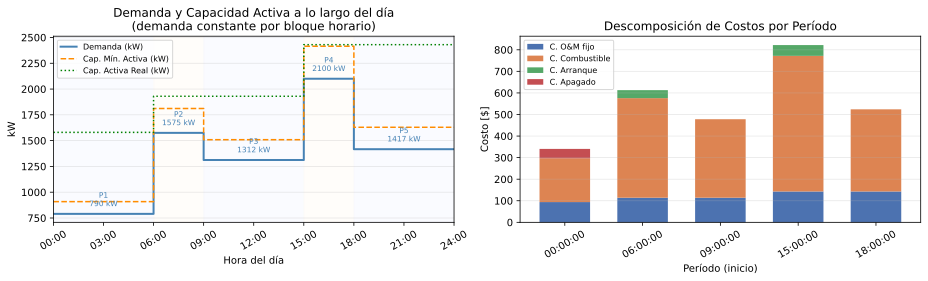

In [102]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']
sns.set_palette(sns.color_palette("deep"))

# ── Duración real de cada período (horas) ────────────────────────────────────
period_end = pd.Timestamp("2024-01-02 00:00:00")
starts_ts  = list(TIME_PERIODS)
ends_ts    = starts_ts[1:] + [period_end]

def ts_to_hour(ts):
    """Convierte timestamp a hora decimal; medianoche del día siguiente → 24."""
    h = ts.hour + ts.minute / 60
    return 24.0 if (h == 0 and ts.date() > starts_ts[0].date()) else h

def make_step_signal(values):
    xs, ys = [], []
    for s, e, v in zip(starts_ts, ends_ts, values):
        xs += [ts_to_hour(s), ts_to_hour(e)]
        ys += [v, v]
    return xs, ys

demand_vals  = list(time_period_data['expected_demand'])
min_cap_vals = list(time_period_data['minimum_active_capacity'])
act_cap_vals = list(results_summary['Cap. Activa Real (kW)'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Gráfico 1: Demanda vs capacidad activa (escalones por duración real) ─────
ax1 = axes[0]

xs_d,  ys_d  = make_step_signal(demand_vals)
xs_mc, ys_mc = make_step_signal(min_cap_vals)
xs_ac, ys_ac = make_step_signal(act_cap_vals)

ax1.plot(xs_d,  ys_d,  color='steelblue',  lw=2,   label='Demanda (kW)')
ax1.plot(xs_mc, ys_mc, color='darkorange',  lw=1.5, ls='--', label='Cap. Mín. Activa (kW)')
ax1.plot(xs_ac, ys_ac, color='green',       lw=1.5, ls=':',  label='Cap. Activa Real (kW)')

colors_bg = ['#f0f4ff', '#fff8f0'] * 3
for s, e, c in zip(starts_ts, ends_ts, colors_bg):
    ax1.axvspan(ts_to_hour(s), ts_to_hour(e), alpha=0.35, color=c, zorder=0)

for i, (s, e, d) in enumerate(zip(starts_ts, ends_ts, demand_vals)):
    mid = (ts_to_hour(s) + ts_to_hour(e)) / 2
    ax1.text(mid, d + 60, f'P{i+1}\n{d:.0f} kW', ha='center', va='bottom', fontsize=7.5, color='steelblue')

ax1.set_xlabel("Hora del día")
ax1.set_ylabel("kW")
ax1.set_title("Demanda y Capacidad Activa a lo largo del día\n(demanda constante por bloque horario)")
ax1.set_xlim(0, 24)
ax1.set_xticks(range(0, 25, 3))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 3)], rotation=30)
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# ── Gráfico 2: Descomposición de costos por período ───────────────────────
ax2 = axes[1]
period_costs = pd.DataFrame(index=[str(t.time()) for t in TIME_PERIODS])
for component, label in [
    ('cost_fixed ($)',    'C. O&M fijo'),
    ('cost_fuel ($)',     'C. Combustible'),
    ('cost_startup ($)',  'C. Arranque'),
    ('cost_shutdown ($)', 'C. Apagado'),
]:
    period_costs[label] = solution.groupby('time_period')[component].sum().values

period_costs.plot.bar(ax=ax2, stacked=True, width=0.65)
ax2.set_xlabel("Período (inicio)"); ax2.set_ylabel("Costo [$]")
ax2.set_title("Descomposición de Costos por Período")
ax2.legend(fontsize=8, loc='upper left')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Heatmap generadores activos por clase y periodo

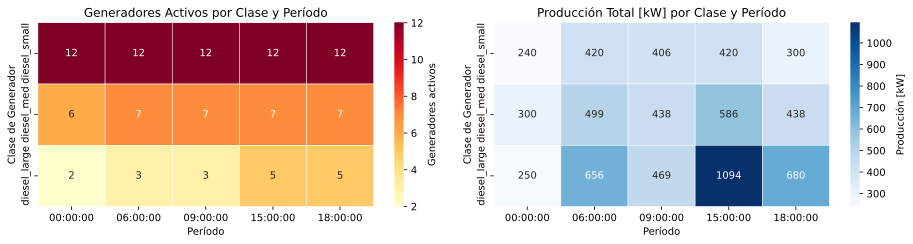

In [103]:
active_matrix = pd.DataFrame(
    index=GENERATORS,
    columns=[str(t.time()) for t in TIME_PERIODS],
    data=[
        [int(round(pe.value(model.num_active[g, i]))) for i in T]
        for g in GENERATORS
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

# Heatmap de generadores activos
sns.heatmap(active_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Generadores activos'}, ax=axes[0])
axes[0].set_title("Generadores Activos por Clase y Período")
axes[0].set_xlabel("Período"); axes[0].set_ylabel("Clase de Generador")

# Heatmap de producción total por clase y período
output_matrix = pd.DataFrame(
    index=GENERATORS,
    columns=[str(t.time()) for t in TIME_PERIODS],
    data=[
        [round(pe.value(model.output[g, i]), 1) for i in T]
        for g in GENERATORS
    ]
)
sns.heatmap(output_matrix, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Producción [kW]'}, ax=axes[1])
axes[1].set_title("Producción Total [kW] por Clase y Período")
axes[1].set_xlabel("Período"); axes[1].set_ylabel("Clase de Generador")

plt.tight_layout()
plt.show()

### Visualización de arranques y apagados

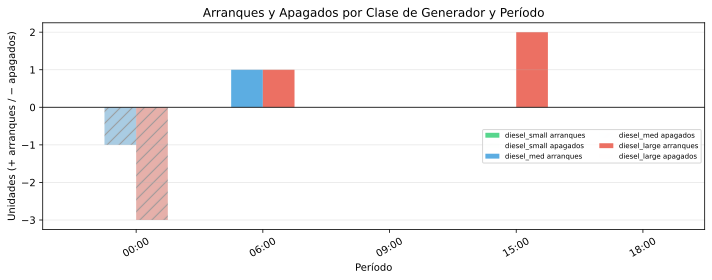

In [104]:
fig, ax = plt.subplots(figsize=(10, 4))
width = 0.25
x = np.arange(len(TIME_PERIODS))
labels = [t.strftime('%H:%M') for t in TIME_PERIODS]
colors_start = ['#2ecc71', '#3498db', '#e74c3c']
colors_stop  = ['#27ae60', '#2980b9', '#c0392b']

for idx, g in enumerate(GENERATORS):
    starts = [int(round(pe.value(model.num_startup[g, i])))  for i in T]
    stops  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]
    offset = (idx - 1) * width
    ax.bar(x + offset - width/2, starts, width, color=colors_start[idx], alpha=0.8, label=f'{g} arranques')
    ax.bar(x + offset - width/2, [-s for s in stops], width, color=colors_stop[idx], alpha=0.4, hatch='//', label=f'{g} apagados')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30)
ax.set_xlabel("Período"); ax.set_ylabel("Unidades (+ arranques / − apagados)")
ax.set_title("Arranques y Apagados por Clase de Generador y Período")
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1, 0.5))
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Estadísticas globales

In [105]:
print("\nEstadísticas globales:")
print(f"   Costo total óptimo   : ${costo_total:,.2f}")
print(f"   Clases generadores   : {len(GENERATORS)}")
print(f"   Períodos             : {len(T)}")
print(f"   Total unidades       : {sum(num_available.values())}")
print(f"   Segmentos lin.       : {N_SEG}")

total_starts = sum(int(round(pe.value(model.num_startup[g, i])))  for g in GENERATORS for i in T)
total_stops  = sum(int(round(pe.value(model.num_shutdown[g, i]))) for g in GENERATORS for i in T)
print(f"   Total arranques      : {total_starts}")
print(f"   Total apagados       : {total_stops}")
print(f"   Costo medio por kWh  : ${costo_total / sum(expected_demand.values()):.4f}/kWh")


Estadísticas globales:
   Costo total óptimo   : $2,776.91
   Clases generadores   : 3
   Períodos             : 5
   Total unidades       : 27
   Segmentos lin.       : 3
   Total arranques      : 4
   Total apagados       : 4
   Costo medio por kWh  : $0.3860/kWh


## Conclusiones

Este modelo implementa un Unit Commitment + Despacho Económico para una microrred diesel con las siguientes extensiones sobre el ejemplo original de Williams:

1. Redimensionamiento a escala de microrred: la demanda fue escalada de ~45 GW (problema nacional) a ~2,1 MW (pico de microrred), con tres clases de generadores diesel de 40, 100 y 250 kW.

2. Costos de apagado: la variable `num_shutdown` y el parámetro `shutdown_cost` capturan los costos de detención de los grupos diesel (fijados en el 50% del costo de arranque, según Nemati et al.).

3. Tiempos mínimos de encendido/apagado: las restricciones MUT y MDT obligan a las unidades a permanecer en su estado actual por al menos el tiempo indicado tras un cambio, evitando el ciclado excesivo y respetando las recomendaciones de Parisio (2014).

4. Linealización Parisio de la curva de combustible: la variable auxiliar $\sigma_{g,t}$ y las restricciones de segmentos tangentes reemplazan el término cuadrático de consumo de combustible por una aproximación lineal convexa por partes, manteniendo la naturaleza MILP del problema (más eficiente que MIQP).

5. Descomposición de costos: el modelo desglosa el costo total en cuatro componentes (O&M, combustible, arranque, apagado), facilitando el análisis económico de la operación de la microrred.